# FT-NIR Glucose w/w analysis

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from clustering import plot_PCA, plot_PHATE, plot_UMAP, plot_TSNE

## Load Data

In [112]:
mean_fs_data = pd.read_csv('../data/data_processing/mean_flour_sugar_data.csv', index_col=0)
fs_data = pd.read_csv('../data/data_processing/processed_flour_sugar_data.csv', index_col=0)
mean_food_data = pd.read_csv('../data/data_processing/mean_foods_data.csv', index_col=0)
foods_data = pd.read_csv('../data/data_processing/processed_foods_data.csv', index_col=0)
fs_data

,4501.041,4504.898,4508.755,4512.612,4516.469,4520.326,4524.183,4528.04,4531.896,4535.754,...,9966.316,9970.173,9974.03,9977.887,9981.744,9985.601,9989.458,9993.314,9997.172,10001.03
0.0,0.368909,0.371250,0.365693,0.365159,0.360829,0.357576,0.355040,0.356554,0.354889,0.347379,...,0.184542,0.178153,0.177718,0.180572,0.173209,0.168235,0.171978,0.176712,0.172280,0.168966
0.0,0.174039,0.171243,0.155967,0.157244,0.160958,0.160517,0.163248,0.159695,0.159699,0.164543,...,0.148533,0.146436,0.142626,0.145708,0.151303,0.145216,0.132038,0.135004,0.136618,0.140038
0.0,0.136935,0.121657,0.128571,0.139961,0.128281,0.116669,0.125559,0.130501,0.128288,0.118640,...,0.061725,0.052813,0.050689,0.058184,0.062055,0.062467,0.065904,0.058885,0.050026,0.049251
0.0,0.406242,0.400763,0.402500,0.402956,0.405200,0.405639,0.394606,0.392809,0.388402,0.392009,...,0.068231,0.065292,0.067868,0.072777,0.068126,0.062028,0.065154,0.067731,0.067351,0.065652
0.0,0.362856,0.353994,0.346843,0.346984,0.347116,0.345381,0.343901,0.345708,0.334150,0.325251,...,0.142166,0.144459,0.144330,0.146200,0.151574,0.146458,0.141956,0.135055,0.132481,0.141057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1.0,0.555258,0.556772,0.560092,0.556223,0.554091,0.554223,0.552431,0.560476,0.564071,0.570377,...,0.062581,0.061989,0.061168,0.060477,0.058960,0.063098,0.066309,0.062699,0.063096,0.061129
1.0,0.586003,0.593413,0.589558,0.598289,0.603600,0.606577,0.610223,0.606317,0.603439,0.606896,...,0.123145,0.124818,0.124524,0.126314,0.127380,0.129594,0.127124,0.126583,0.124586,0.125121
1.0,0.579945,0.592876,0.584950,0.580428,0.582088,0.575230,0.575615,0.583541,0.583483,0.592932,...,0.080313,0.077472,0.077117,0.078712,0.079774,0.082540,0.079884,0.077831,0.076295,0.074526
1.0,0.570594,0.573988,0.576377,0.572245,0.578236,0.583994,0.586108,0.586958,0.589191,0.591778,...,0.045519,0.042929,0.042077,0.044491,0.044328,0.043269,0.042787,0.042323,0.040255,0.040373


In [113]:
foods_data

,4501.041,4504.898,4508.755,4512.612,4516.469,4520.326,4524.183,4528.04,4531.896,4535.754,...,9966.316,9970.173,9974.03,9977.887,9981.744,9985.601,9989.458,9993.314,9997.172,10001.03
buttermilk_biscuit,0.122664,0.119158,0.118186,0.120337,0.116341,0.121818,0.118069,0.118523,0.117388,0.117533,...,0.129149,0.123983,0.127351,0.134723,0.134399,0.124427,0.122702,0.125254,0.125208,0.131721
buttermilk_biscuit,0.154507,0.159807,0.159816,0.154425,0.143698,0.143324,0.142306,0.142803,0.148112,0.153268,...,0.148150,0.155304,0.155804,0.153847,0.154194,0.154129,0.152694,0.151190,0.152332,0.154823
buttermilk_biscuit,0.094460,0.104606,0.103955,0.090875,0.081105,0.083055,0.087677,0.089758,0.092323,0.090808,...,0.088762,0.095695,0.096416,0.094081,0.097831,0.098508,0.094591,0.095812,0.105010,0.099529
buttermilk_biscuit,0.172335,0.163363,0.154461,0.156848,0.164239,0.158716,0.156849,0.148939,0.162078,0.156832,...,0.161242,0.164884,0.165316,0.169488,0.168322,0.160556,0.158540,0.163411,0.165075,0.167231
buttermilk_biscuit,0.074529,0.079687,0.067179,0.057828,0.058841,0.067121,0.063869,0.075982,0.080948,0.069836,...,0.082871,0.099798,0.102654,0.102634,0.097374,0.102575,0.098238,0.090184,0.087354,0.087982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tapioca,0.736911,0.758390,0.772296,0.762103,0.751066,0.741194,0.729086,0.739743,0.736907,0.738242,...,0.041507,0.044871,0.048024,0.035699,0.044883,0.051959,0.067735,0.043422,0.023820,0.034843
tapioca,0.391639,0.390784,0.381159,0.378581,0.382307,0.381294,0.372819,0.372148,0.372172,0.378100,...,0.027148,0.037206,0.027121,0.022108,0.018667,0.022775,0.021592,0.018780,0.007594,0.019250
tapioca,0.450305,0.456324,0.446130,0.442380,0.441973,0.441261,0.430501,0.432847,0.437812,0.438709,...,0.022731,0.024733,0.031141,0.031272,0.027171,0.027428,0.033350,0.028102,0.021829,0.025048
tapioca,0.418569,0.427700,0.432843,0.426549,0.412199,0.404726,0.402743,0.405451,0.410520,0.410920,...,0.088886,0.095433,0.087756,0.078706,0.081031,0.085321,0.095764,0.088299,0.080859,0.086463


In [115]:
labels = [0, 0.025, 0.05, 0.10, 0.15, 0.25, 0.35, 0.45, 0.5, 0.55, 0.65, 0.75, 1]
food_labels = ["buttermilk_biscuit", "inst_potatoes", "mixed_gravy", "nonfat_milk", "parmesan", "parmesan_romano", "protein_pancake", "tapioca"]
waves = [float(col) for col in fs_data.columns]

In [116]:
# foods_glucose_map = {
#     "buttermilk_biscuit": 0.04,
#     "inst_potatoes": 0.004,
#     "mixed_gravy": 0.025,
#     "nonfat_milk": 0,
#     "parmesan": 0,
#     "parmesan_romano": 0,
#     "protein_pancake": 0.045,
#     "tapioca": 0.002
# }

In [117]:
## Total sugars
foods_glucose_map = {
    "buttermilk_biscuit": 0.068,
    "inst_potatoes": 0.008,
    "mixed_gravy": 0.0325,
    "nonfat_milk": 0.12,
    "parmesan": 0,
    "parmesan_romano": 0,
    "protein_pancake": 0.085,
    "tapioca": 0.002
}

## Visualize Spectra

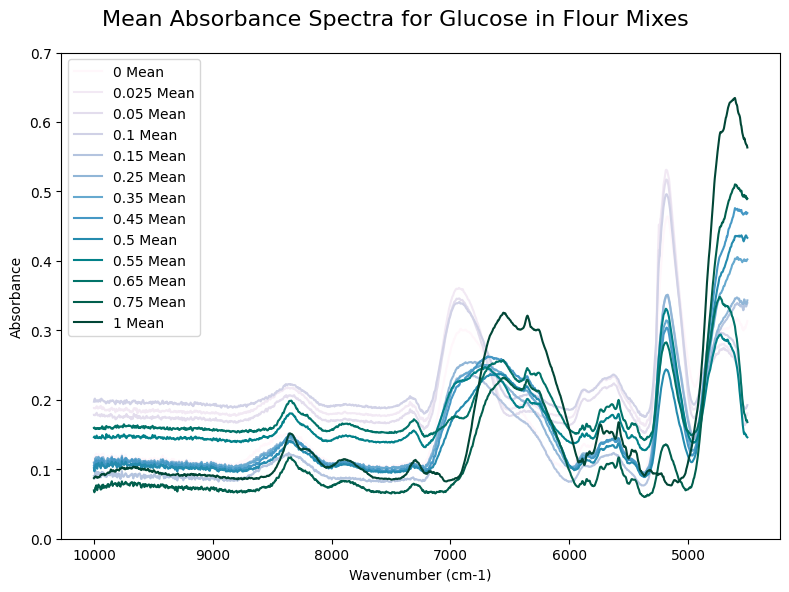

In [118]:
fig, ax = plt.subplots(figsize=(8,6))
# panels = ["A.", "B.", "C.", "D."]
cmap = plt.colormaps['PuBuGn']
n_lines = len(labels)

for i in range(len(labels)):
    line_color = cmap(i / (n_lines - 1))
    ax.plot(waves, mean_fs_data.loc[labels[i]], color=line_color,label=str(labels[i])+" Mean", alpha=1)
    
ax.set_xlabel("Wavenumber (cm-1)")
ax.set_ylabel("Absorbance")
ax.legend()
ax.invert_xaxis()
ax.set_ylim(0,0.7)
fig.suptitle('Mean Absorbance Spectra for Glucose in Flour Mixes', fontsize=16)
plt.tight_layout()
plt.savefig('../figures/mean_spectra_glucose_flour.png', dpi=300)
plt.show()

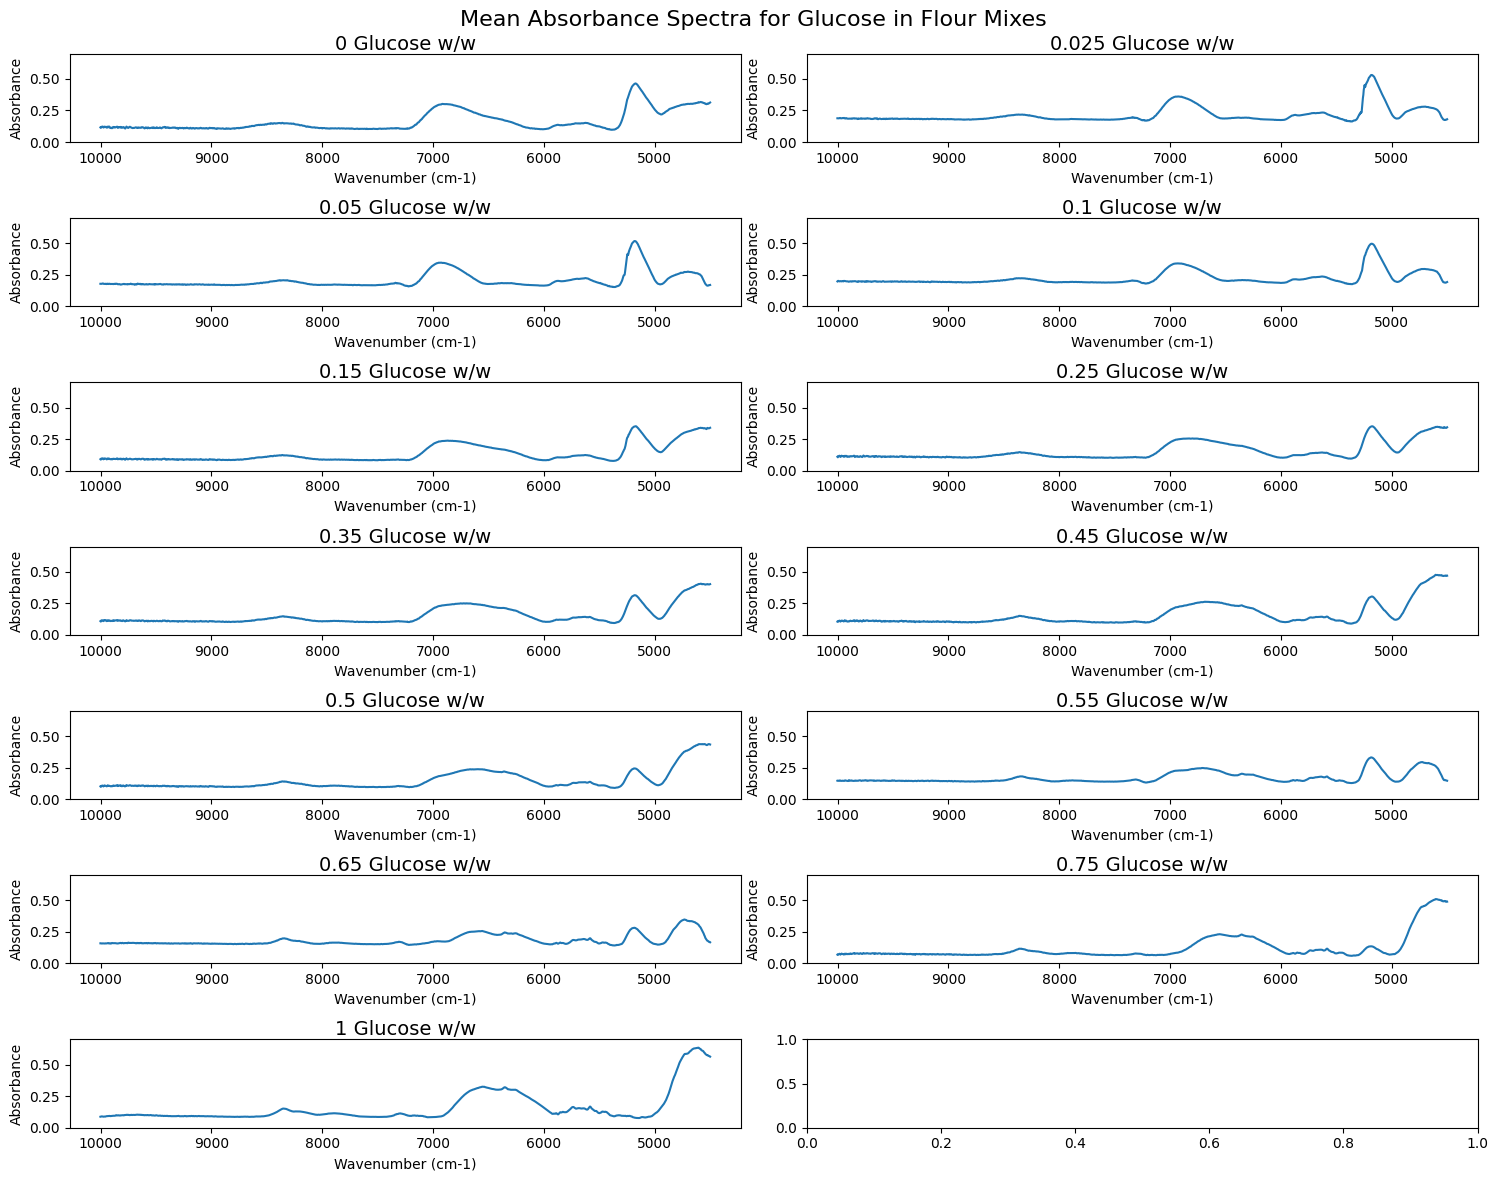

In [119]:
fig, axs = plt.subplots(7,2, figsize=(15,12))
# panels = ["A.", "B.", "C.", "D."]
for i, ax in enumerate(axs.flatten()):
    if i == len(labels):
        break
    ax.plot(waves, mean_fs_data.loc[labels[i]], label=str(labels[i])+" Mean")
    ax.set_xlabel("Wavenumber (cm-1)")
    ax.set_ylabel("Absorbance")
    ax.set_title(f'{labels[i]} Glucose w/w', y=0.95, fontsize=14)
    # ax.annotate(panels[i], xy=(0.02, 0.99), xycoords='axes fraction', fontsize=14, fontweight='bold', va='top')
    ax.invert_xaxis()
    ax.set_ylim(0,0.7)
    # ax.legend(loc='lower right')
fig.suptitle('Mean Absorbance Spectra for Glucose in Flour Mixes', fontsize=16)
plt.tight_layout()
plt.show()

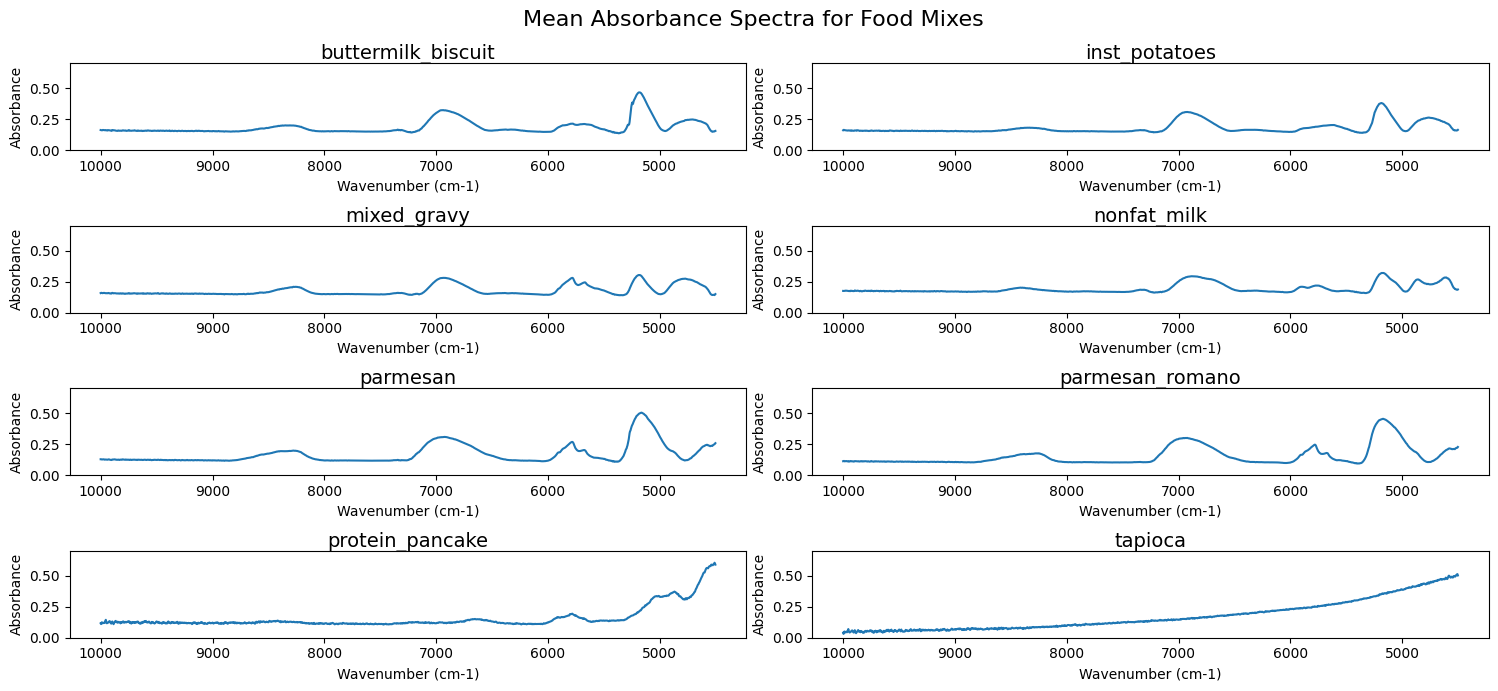

In [120]:
fig, axs = plt.subplots(4,2, figsize=(15,7))
# panels = ["A.", "B.", "C.", "D."]
for i, ax in enumerate(axs.flatten()):
    # if i == len(food_labels):
    #     break
    ax.plot(waves, mean_food_data.loc[food_labels[i]], label=str(labels[i])+" Mean")
    ax.set_xlabel("Wavenumber (cm-1)")
    ax.set_ylabel("Absorbance")
    ax.set_title(food_labels[i], y=0.95, fontsize=14)
    # ax.annotate(panels[i], xy=(0.02, 0.99), xycoords='axes fraction', fontsize=14, fontweight='bold', va='top')
    ax.invert_xaxis()
    ax.set_ylim(0,0.7)
    # ax.legend(loc='lower right')
fig.suptitle('Mean Absorbance Spectra for Food Mixes', fontsize=16)
plt.tight_layout()
plt.show()

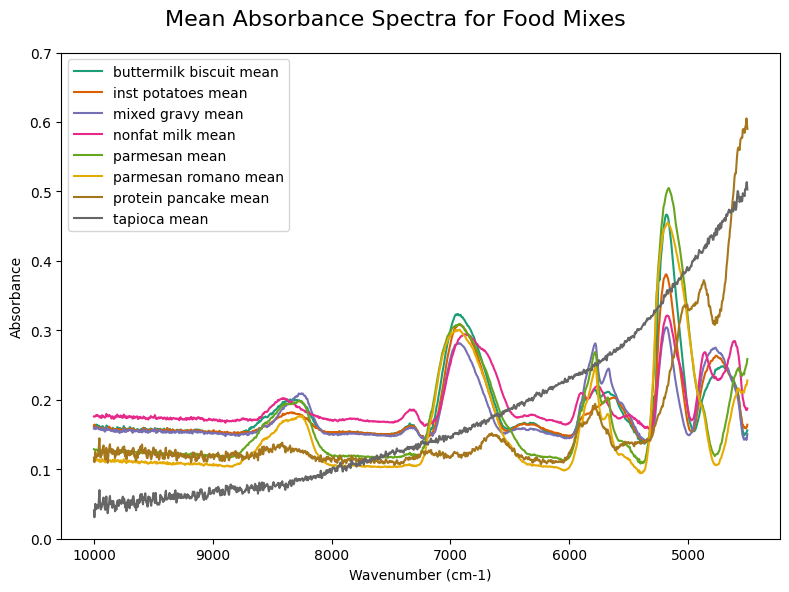

In [121]:
fig, ax = plt.subplots(figsize=(8,6))
# panels = ["A.", "B.", "C.", "D."]
cmap = plt.colormaps['Dark2']
n_lines = len(food_labels)

for i in range(len(food_labels)):
    line_color = cmap(i / (n_lines - 1))
    ax.plot(waves, mean_food_data.loc[food_labels[i]], color=line_color,label=str(food_labels[i]).replace('_', ' ')+" mean", alpha=1)
    
ax.set_xlabel("Wavenumber (cm-1)")
ax.set_ylabel("Absorbance")
ax.legend()
ax.invert_xaxis()
ax.set_ylim(0,0.7)
fig.suptitle('Mean Absorbance Spectra for Food Mixes', fontsize=16)
plt.savefig('../figures/mean_spectra_foods.png', dpi=300)
plt.tight_layout()
plt.show()

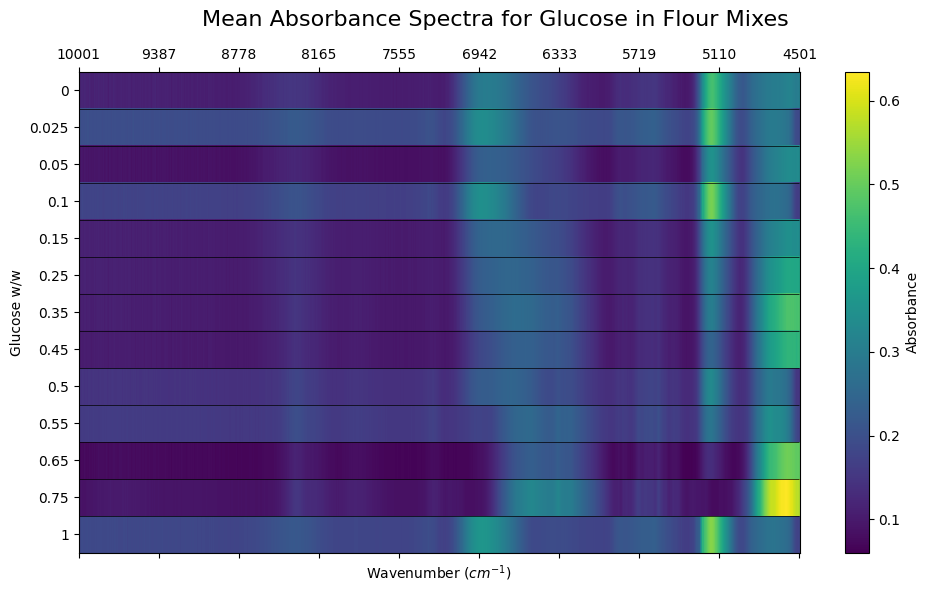

In [122]:
fig, ax = plt.subplots(figsize=(10,6))
mat = ax.matshow(mean_fs_data.values, cmap='viridis', aspect='auto')

ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels)
ax.set_xticks(np.linspace(0, len(waves) - 1, num=10))
ax.set_xticklabels([int(waves[int(i)]) for i in np.linspace(0, len(waves) - 1, num=10)])

ax.invert_xaxis()
ax.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax.set_ylabel("Glucose w/w")

ax.hlines(np.arange(len(labels)-1)+0.5, xmin=0, xmax=len(waves)-1, colors='k', linewidth=0.5)

fig.colorbar(mat, ax=ax, label="Absorbance")
fig.suptitle('Mean Absorbance Spectra for Glucose in Flour Mixes', fontsize=16)

plt.tight_layout()
plt.show()

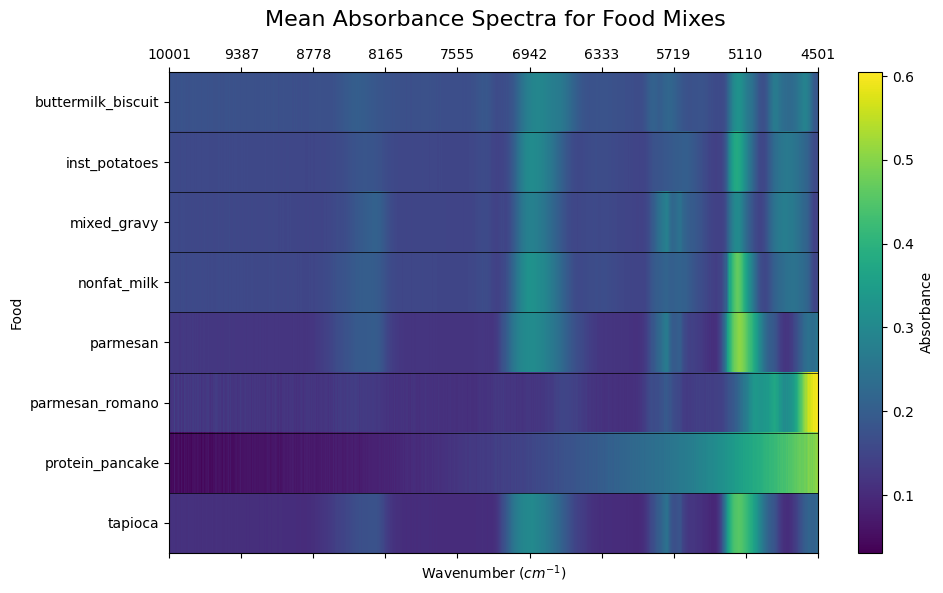

In [123]:
fig, ax = plt.subplots(figsize=(10,6))
mat = ax.matshow(mean_food_data.values, cmap='viridis', aspect='auto')

ax.set_yticks(np.arange(len(food_labels)))
ax.set_yticklabels(food_labels)
ax.set_xticks(np.linspace(0, len(waves) - 1, num=10))
ax.set_xticklabels([int(waves[int(i)]) for i in np.linspace(0, len(waves) - 1, num=10)])

ax.invert_xaxis()
ax.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax.set_ylabel("Food")

ax.hlines(np.arange(len(food_labels)-1)+0.5, xmin=0, xmax=len(waves)-1, colors='k', linewidth=0.5)

fig.colorbar(mat, ax=ax, label="Absorbance")
fig.suptitle('Mean Absorbance Spectra for Food Mixes', fontsize=16)

plt.tight_layout()
plt.show()

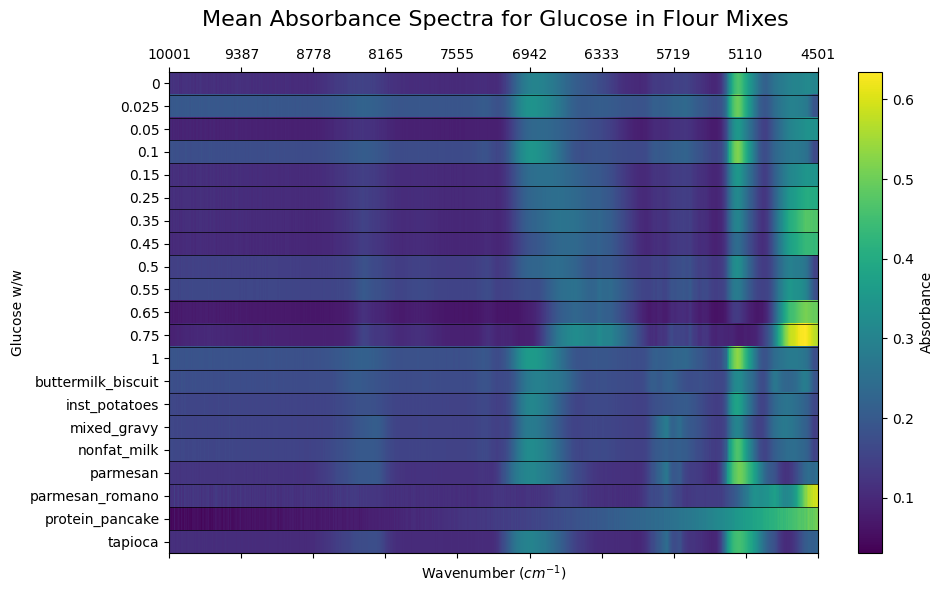

In [124]:
fig, ax = plt.subplots(figsize=(10,6))
mat = ax.matshow(np.concat([mean_fs_data.values, mean_food_data.values], axis=0), cmap='viridis', aspect='auto')

ax.set_yticks(np.arange(len(labels+food_labels)))
ax.set_yticklabels(labels+food_labels)
ax.set_xticks(np.linspace(0, len(waves) - 1, num=10))
ax.set_xticklabels([int(waves[int(i)]) for i in np.linspace(0, len(waves) - 1, num=10)])

ax.invert_xaxis()
ax.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax.set_ylabel("Glucose w/w")

ax.hlines(np.arange(len(labels+food_labels)-1)+0.5, xmin=0, xmax=len(waves)-1, colors='k', linewidth=0.5)

fig.colorbar(mat, ax=ax, label="Absorbance")
fig.suptitle('Mean Absorbance Spectra for Glucose in Flour Mixes', fontsize=16)

plt.tight_layout()
plt.show()

## ML Clustering

In [125]:
#read the data
n = len(fs_data.columns)
X_features = fs_data.iloc[:, 1:n]
y_label = fs_data.index

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 293 samples in 0.000s...
[t-SNE] Computed neighbors for 293 samples in 0.011s...
[t-SNE] Computed conditional probabilities for sample 293 / 293
[t-SNE] Mean sigma: 0.934392
[t-SNE] KL divergence after 250 iterations with early exaggeration: 52.206352
[t-SNE] KL divergence after 800 iterations: 0.335580
Calculating PHATE...
  Running PHATE on 293 observations and 1426 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.03 seconds.
    Calculating KNN search...
    Calculating affinities...
  Calculated graph and diffusion operator in 0.04 seconds.
  Calculating diffusion potential...
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by 2.8% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 0.23 seconds.
Calculated PHATE in 0.28 seconds.


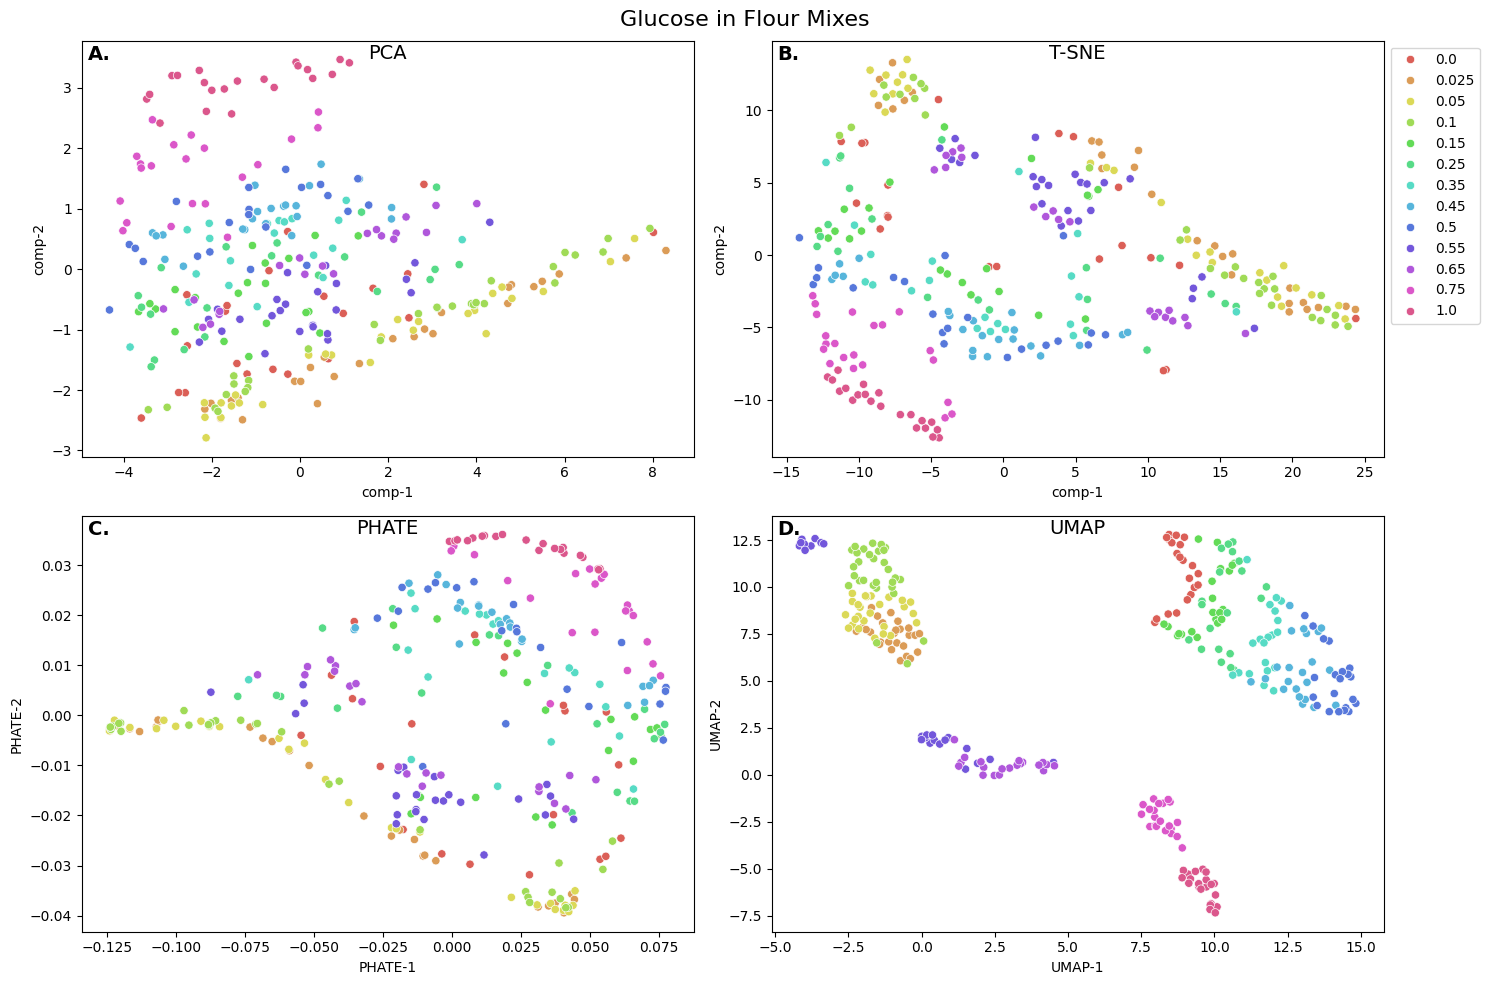

In [126]:
fig, axs = plt.subplots(2,2, figsize=(15,10))
ax = axs.flatten()

plot_PCA(X_features, y_label, ax[0])
plot_TSNE(X_features, y_label, ax[1])
plot_PHATE(X_features, y_label, ax[2], knn=25)
plot_UMAP(X_features, y_label, ax[3])

panels = ["A.", "B.", "C.", "D."]
ML_labels = ["PCA", "T-SNE", "PHATE", "UMAP"]
for a, panel, label in zip(ax, panels, ML_labels):
    a.text(0.01, 0.99, panel,
           transform=a.transAxes,
           fontsize=14,
           fontweight='bold',
           va='top')
    a.set_title(label, fontsize=14, y=0.935)
    if label == "T-SNE":
        a.legend(loc='upper left', bbox_to_anchor=(1, 1))
    else:
        a.get_legend().remove()

fig.suptitle("Glucose in Flour Mixes", fontsize=16)
plt.savefig('../figures/clustering_glucose_flour.png', dpi=300)
plt.tight_layout()
plt.show()

In [127]:
combined_data = pd.concat([fs_data, foods_data], axis=0)
combined_data

,4501.041,4504.898,4508.755,4512.612,4516.469,4520.326,4524.183,4528.04,4531.896,4535.754,...,9966.316,9970.173,9974.03,9977.887,9981.744,9985.601,9989.458,9993.314,9997.172,10001.03
0.0,0.368909,0.371250,0.365693,0.365159,0.360829,0.357576,0.355040,0.356554,0.354889,0.347379,...,0.184542,0.178153,0.177718,0.180572,0.173209,0.168235,0.171978,0.176712,0.172280,0.168966
0.0,0.174039,0.171243,0.155967,0.157244,0.160958,0.160517,0.163248,0.159695,0.159699,0.164543,...,0.148533,0.146436,0.142626,0.145708,0.151303,0.145216,0.132038,0.135004,0.136618,0.140038
0.0,0.136935,0.121657,0.128571,0.139961,0.128281,0.116669,0.125559,0.130501,0.128288,0.118640,...,0.061725,0.052813,0.050689,0.058184,0.062055,0.062467,0.065904,0.058885,0.050026,0.049251
0.0,0.406242,0.400763,0.402500,0.402956,0.405200,0.405639,0.394606,0.392809,0.388402,0.392009,...,0.068231,0.065292,0.067868,0.072777,0.068126,0.062028,0.065154,0.067731,0.067351,0.065652
0.0,0.362856,0.353994,0.346843,0.346984,0.347116,0.345381,0.343901,0.345708,0.334150,0.325251,...,0.142166,0.144459,0.144330,0.146200,0.151574,0.146458,0.141956,0.135055,0.132481,0.141057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tapioca,0.736911,0.758390,0.772296,0.762103,0.751066,0.741194,0.729086,0.739743,0.736907,0.738242,...,0.041507,0.044871,0.048024,0.035699,0.044883,0.051959,0.067735,0.043422,0.023820,0.034843
tapioca,0.391639,0.390784,0.381159,0.378581,0.382307,0.381294,0.372819,0.372148,0.372172,0.378100,...,0.027148,0.037206,0.027121,0.022108,0.018667,0.022775,0.021592,0.018780,0.007594,0.019250
tapioca,0.450305,0.456324,0.446130,0.442380,0.441973,0.441261,0.430501,0.432847,0.437812,0.438709,...,0.022731,0.024733,0.031141,0.031272,0.027171,0.027428,0.033350,0.028102,0.021829,0.025048
tapioca,0.418569,0.427700,0.432843,0.426549,0.412199,0.404726,0.402743,0.405451,0.410520,0.410920,...,0.088886,0.095433,0.087756,0.078706,0.081031,0.085321,0.095764,0.088299,0.080859,0.086463


In [128]:
#read the data
n = len(combined_data.columns)
X_features = combined_data.iloc[:, 1:n]
y_label = combined_data.index

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 459 samples in 0.001s...
[t-SNE] Computed neighbors for 459 samples in 0.006s...
[t-SNE] Computed conditional probabilities for sample 459 / 459
[t-SNE] Mean sigma: 0.800333
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.126907
[t-SNE] KL divergence after 1000 iterations: 0.397856
Calculating PHATE...
  Running PHATE on 459 observations and 1426 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.02 seconds.
    Calculating KNN search...
    Calculating affinities...
  Calculated graph and diffusion operator in 0.04 seconds.
  Calculating diffusion potential...
  Calculating metric MDS...
  Calculated metric MDS in 0.49 seconds.
Calculated PHATE in 0.53 seconds.


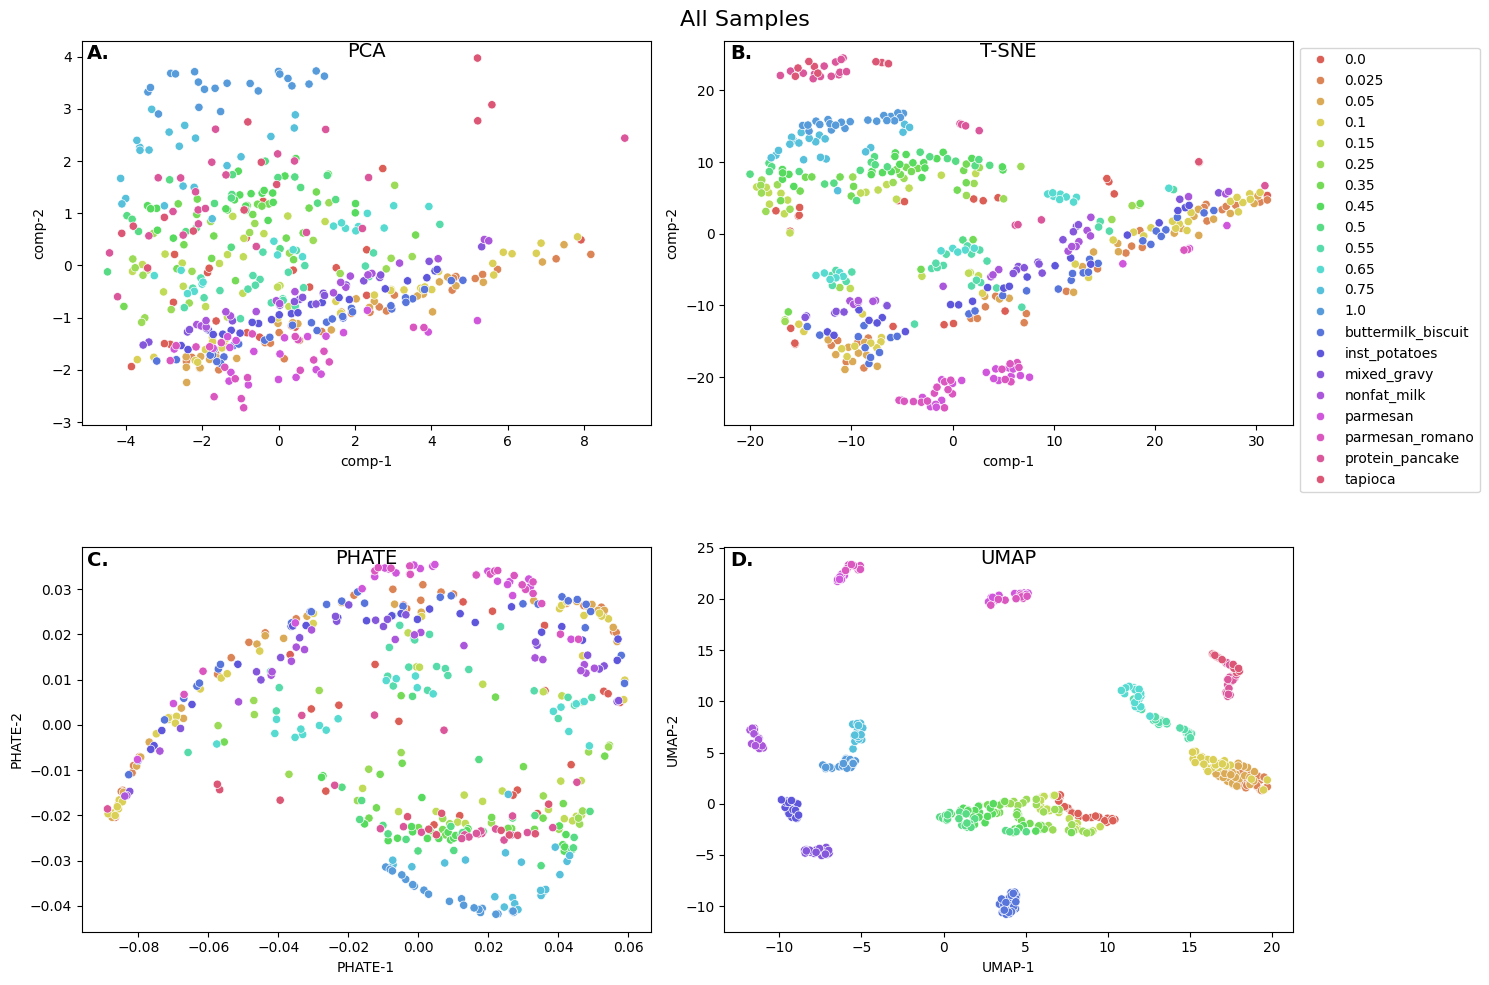

In [129]:
fig, axs = plt.subplots(2,2, figsize=(15,10))
ax = axs.flatten()

plot_PCA(X_features, y_label, ax[0])
plot_TSNE(X_features, y_label, ax[1])
plot_PHATE(X_features, y_label, ax[2], knn=25)
plot_UMAP(X_features, y_label, ax[3])

panels = ["A.", "B.", "C.", "D."]
ML_labels = ["PCA", "T-SNE", "PHATE", "UMAP"]
for a, panel, label in zip(ax, panels, ML_labels):
    a.text(0.01, 0.99, panel,
           transform=a.transAxes,
           fontsize=14,
           fontweight='bold',
           va='top')
    a.set_title(label, fontsize=14, y=0.935)
    if label == "T-SNE":
        a.legend(loc='upper left', bbox_to_anchor=(1, 1))
    else:
        a.get_legend().remove()

fig.suptitle("All Samples", fontsize=16)
plt.tight_layout()
plt.show()

## PLS Model for just Glucose/Flour Mixes

In [130]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

### Split Data
Split into training and testing sets, using just flour/sugar mixes

In [131]:
rng = np.random.RandomState(0)

n = len(fs_data.columns)
X = fs_data.iloc[:, 1:n]
y = fs_data.index
X_train, X_test_all, y_train, y_test_all = train_test_split(X, y, random_state=rng)

### Plot Variance for Number of Components in y

In [132]:
n_comps = []
scores = []
for n in range(1, 11):
    pls = PLSRegression(n_components=n)
    pls.fit(X_train, y_train)
    score = pls.score(X_test_all, y_test_all)
    n_comps.append(n)
    scores.append(score)

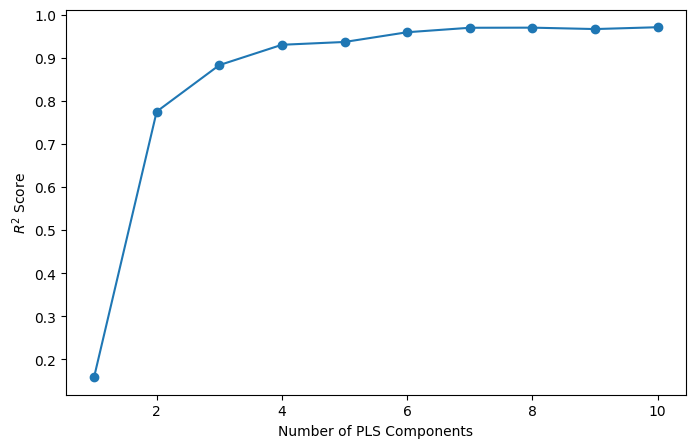

In [133]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(n_comps, scores, marker='o')
ax.set_ylabel(r"$R^2$ Score")
ax.set_xlabel("Number of PLS Components")
plt.show()

### Plot Predictions versus Data

In [134]:
pls = PLSRegression(n_components=4)
pls.fit(X_train, y_train)
X_proj_all = pls.transform(X_test_all)[:, 0]

RMSEP: 0.0814


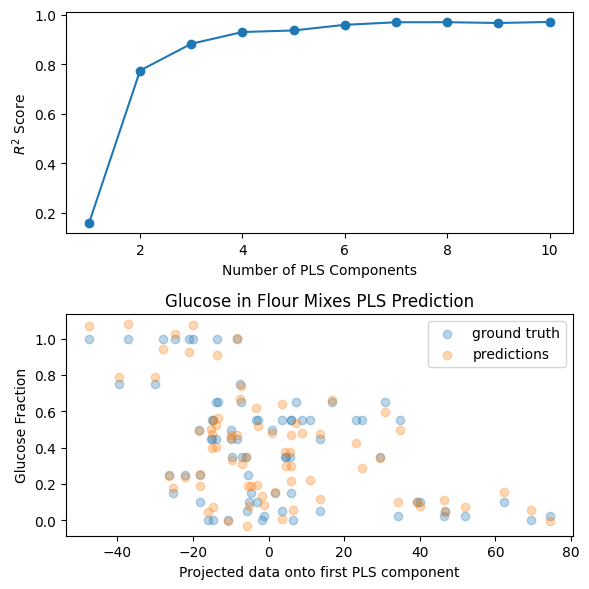

In [135]:
fig, ax = plt.subplots(2,1, figsize=(6,6))

ax[0].plot(n_comps, scores, marker='o')
ax[0].set_ylabel(r"$R^2$ Score")
ax[0].set_xlabel("Number of PLS Components")

ax[1].scatter(X_proj_all, y_test_all, alpha=0.3, label="ground truth")
y_pred_all = pls.predict(X_test_all)
ax[1].scatter(X_proj_all, y_pred_all, alpha=0.3, label="predictions")
ax[1].set(xlabel="Projected data onto first PLS component", ylabel="Glucose Fraction", title="Glucose in Flour Mixes PLS Prediction")
legend = ax[1].legend()

rmsep = root_mean_squared_error(y_test_all, y_pred_all)
print(f"RMSEP: {rmsep:.4f}")
plt.tight_layout()
plt.savefig('../figures/pls_glucose_flour.png', dpi=300)
plt.show()

RMSEP: 0.0814


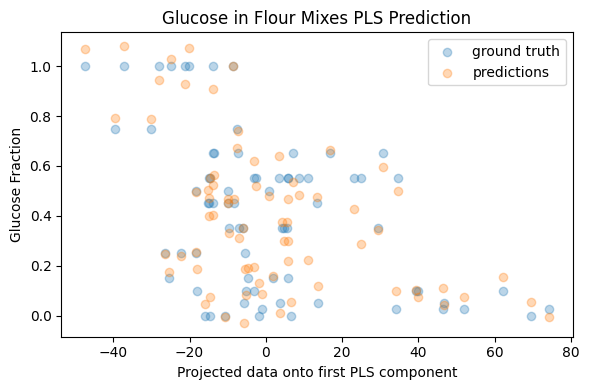

In [136]:
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(X_proj_all, y_test_all, alpha=0.3, label="ground truth")
y_pred_all = pls.predict(X_test_all)
ax.scatter(X_proj_all, y_pred_all, alpha=0.3, label="predictions")
ax.set(xlabel="Projected data onto first PLS component", ylabel="Glucose Fraction", title="Glucose in Flour Mixes PLS Prediction")
legend = ax.legend()

rmsep = root_mean_squared_error(y_test_all, y_pred_all)
print(f"RMSEP: {rmsep:.4f}")
plt.tight_layout()
plt.show()

### For mean data

In [137]:
rng = np.random.RandomState(0)

n = len(mean_fs_data.columns)
X = mean_fs_data.iloc[:, 1:n]
y = mean_fs_data.index
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=rng)

pls = PLSRegression(n_components=4)
pls.fit(X_train, y_train)
X_proj = pls.transform(X_test)[:, 0]

RMSEP: 0.1588


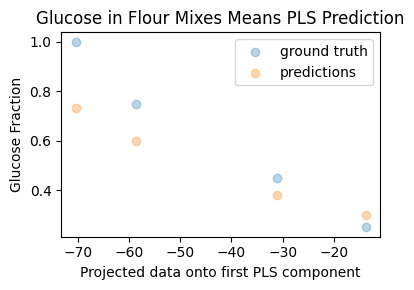

In [138]:
fig, ax = plt.subplots(figsize=(4,3))
ax.scatter(X_proj, y_test, alpha=0.3, label="ground truth")
y_pred = pls.predict(X_test)
ax.scatter(X_proj, y_pred, alpha=0.3, label="predictions")
ax.set(xlabel="Projected data onto first PLS component", ylabel="Glucose Fraction", title="Glucose in Flour Mixes Means PLS Prediction")
legend = ax.legend()

rmsep = root_mean_squared_error(y_test, y_pred)
print(f"RMSEP: {rmsep:.4f}")
plt.tight_layout()
plt.show()

Mean RMSEP: 0.1588
RMSEP: 0.1580


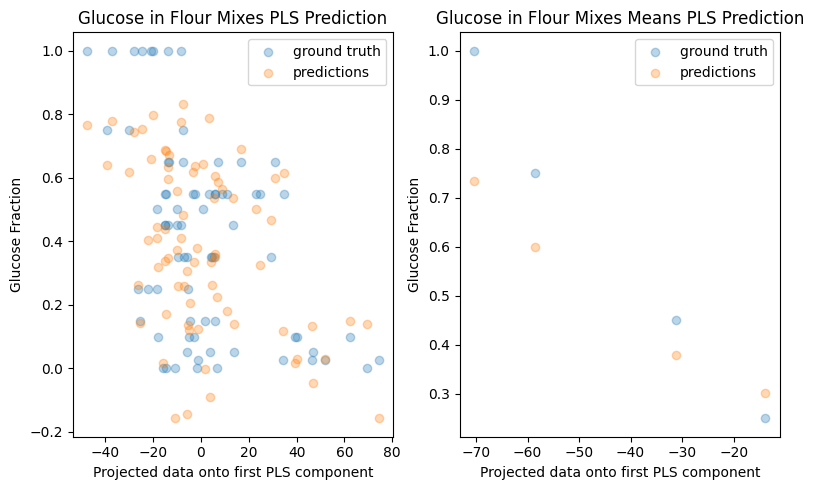

In [139]:
fig, ax = plt.subplots(1,2, figsize=(8,5))
ax[0].scatter(X_proj_all, y_test_all, alpha=0.3, label="ground truth")
y_pred_all = pls.predict(X_test_all)
ax[0].scatter(X_proj_all, y_pred_all, alpha=0.3, label="predictions")
ax[0].set(xlabel="Projected data onto first PLS component", ylabel="Glucose Fraction", title="Glucose in Flour Mixes PLS Prediction")
ax[0].legend()

ax[1].scatter(X_proj, y_test, alpha=0.3, label="ground truth")
y_pred = pls.predict(X_test)
ax[1].scatter(X_proj, y_pred, alpha=0.3, label="predictions")
ax[1].set(xlabel="Projected data onto first PLS component", ylabel="Glucose Fraction", title="Glucose in Flour Mixes Means PLS Prediction")
legend = ax[1].legend()

rmsep = root_mean_squared_error(y_test, y_pred)
print(f"Mean RMSEP: {rmsep:.4f}")

rmsep = root_mean_squared_error(y_test_all, y_pred_all)
print(f"RMSEP: {rmsep:.4f}")
plt.tight_layout()
plt.show()

## PLS Model for all Data
Using Flour/Sugar Mixes as Training and Food Mixes as Testing

In [140]:
n = len(fs_data.columns)
X = fs_data.iloc[:, 1:n]
y = fs_data.index

test_foods = foods_data.drop(index=["tapioca", "parmesan", "parmesan_romano", "nonfat_milk"])
test_foods_labels = list(set(test_foods.index))
y_test = [foods_glucose_map.get(label, label) for label in test_foods.index]
X_test = test_foods.iloc[:, 1:n]
X_proj = pls.transform(X_test)[:, 0]

In [141]:
pls = PLSRegression(n_components=4)
pls.fit(X, y)

,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",4
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06
,"copy copy: bool, default=TrueWhether to copy `X` and `y` in :term:`fit` before applying centering,and potentially scaling. If `False`, these operations will be doneinplace, modifying both arrays.",True


In [142]:
test_foods_labels

['mixed_gravy', 'inst_potatoes', 'protein_pancake', 'buttermilk_biscuit']

In [145]:
y_pred = pls.predict(X_test)
mixtures_pred = pd.DataFrame()
for food in test_foods_labels: 
    mixtures_pred[food] =  y_pred[test_foods.index.get_loc(food)][:20]
mixtures_pred

,mixed_gravy,inst_potatoes,protein_pancake,buttermilk_biscuit
0,0.230787,0.152604,-0.066809,0.078069
1,0.215801,0.172071,-0.119322,0.108798
2,0.207560,0.125602,-0.233447,0.061097
3,0.236070,0.155644,-0.140525,0.110217
4,0.218325,0.162972,-0.004921,0.032775
5,0.226544,0.155116,-0.059697,0.047150
6,0.223212,0.129776,-0.160366,0.113459
7,0.215473,0.225212,-0.071619,0.086017
8,0.251717,0.170642,-0.077965,0.090433
9,0.226513,0.176018,0.020221,0.087550


RMSEP: 0.1547


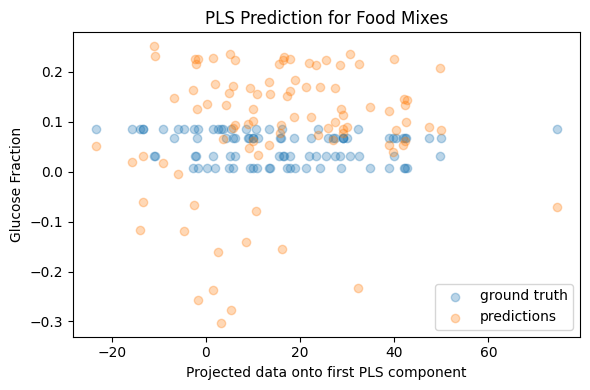

In [148]:
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(X_proj, y_test, alpha=0.3, label="ground truth")
ax.scatter(X_proj, y_pred, alpha=0.3, label="predictions")
ax.set(xlabel="Projected data onto first PLS component", ylabel="Glucose Fraction", title="PLS Prediction for Food Mixes")
legend = ax.legend()

rmsep = root_mean_squared_error(y_test, y_pred)
print(f"RMSEP: {rmsep:.4f}")
plt.tight_layout()
plt.show()

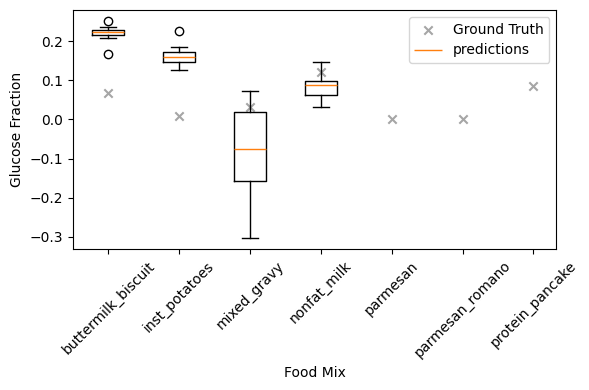

Median values are:
 [np.float64(0.22444136272542864), np.float64(0.1595987951547161), np.float64(-0.07479200824207793), np.float64(0.08746348628566278)]


In [149]:
fgm = {k: v for k, v in foods_glucose_map.items() if k != "tapioca"}

fig, ax = plt.subplots(figsize=(6,4))
x = np.arange(1, len(fgm.keys()) + 1)

ax.scatter(x, fgm.values(), color='grey', marker='x', label="Ground Truth", alpha=0.7)
bs = ax.boxplot(mixtures_pred, label="predictions")
ax.set_xticks(x)
ax.set_xticklabels(fgm.keys(), rotation=45)
ax.set(xlabel="Food Mix", ylabel="Glucose Fraction")

ax.legend()

plt.tight_layout()
plt.show()


medians = [med.get_ydata()[0] for med in bs['medians']]
print("Median values are:\n", medians)

RMSEP: 0.1955


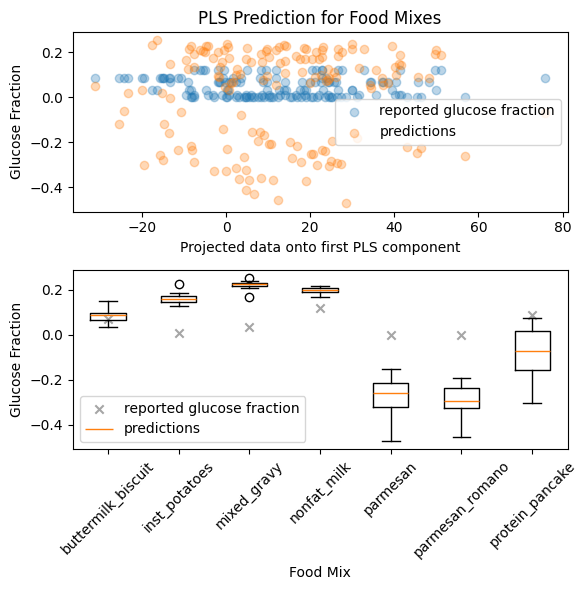

In [77]:
fig, ax = plt.subplots(2,1, figsize=(6,6))
ax[0].scatter(X_proj, y_test, alpha=0.3, label="reported glucose fraction")
ax[0].scatter(X_proj, y_pred, alpha=0.3, label="predictions")
ax[0].set(xlabel="Projected data onto first PLS component", ylabel="Glucose Fraction", title="PLS Prediction for Food Mixes")
legend = ax[0].legend()

ax[1].scatter(x, fgm.values(), color='grey', marker='x', label="reported glucose fraction", alpha=0.7)
bs = ax[1].boxplot(mixtures_pred, label="predictions")
ax[1].set_xticks(x)
ax[1].set_xticklabels(fgm.keys(), rotation=45)
ax[1].set(xlabel="Food Mix", ylabel="Glucose Fraction")

ax[1].legend()

rmsep = root_mean_squared_error(y_test, y_pred)
print(f"RMSEP: {rmsep:.4f}")
plt.tight_layout()
plt.savefig('../figures/pls_food_mix_predictions.png', dpi=300)
plt.show()

### Repeat above but only with Food Data Means

In [34]:
n = len(fs_data.columns)
X = fs_data.iloc[:, 1:n]
y = fs_data.index

test_foods = mean_food_data
test_foods_labels = mean_food_data.index
y_test = [foods_glucose_map.get(label, label) for label in test_foods.index]
X_test = test_foods.iloc[:, 1:n]
X_proj = pls.transform(X_test)[:, 0]

pls = PLSRegression(n_components=4)
pls.fit(X, y)

y_pred = pls.predict(X_test)

RMSEP: 0.1874


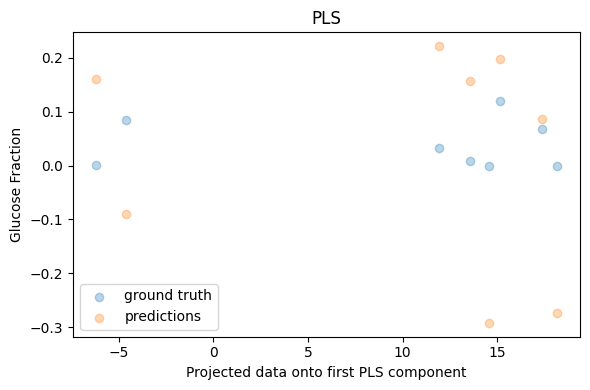

In [35]:
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(X_proj, y_test, alpha=0.3, label="ground truth")
ax.scatter(X_proj, y_pred, alpha=0.3, label="predictions")
ax.set(xlabel="Projected data onto first PLS component", ylabel="Glucose Fraction", title="PLS")
legend = ax.legend()

rmsep = root_mean_squared_error(y_test, y_pred)
print(f"RMSEP: {rmsep:.4f}")
plt.tight_layout()
plt.show()

## PLS for Mean Data
All mean data is split into training and test sets

In [36]:
combined_means = pd.concat([mean_fs_data, mean_food_data], axis=0)
combined_means

,4501.041,4504.898,4508.755,4512.612,4516.469,4520.326,4524.183,4528.04,4531.896,4535.754,...,9966.316,9970.173,9974.03,9977.887,9981.744,9985.601,9989.458,9993.314,9997.172,10001.03
0.0,0.313222,0.310504,0.308032,0.307492,0.303451,0.302590,0.304279,0.304118,0.300165,0.299960,...,0.121401,0.116257,0.114833,0.119916,0.122568,0.119960,0.120457,0.116264,0.111652,0.115936
0.1,0.192415,0.190365,0.189159,0.187611,0.187051,0.188018,0.187925,0.189886,0.190702,0.190889,...,0.197217,0.198847,0.199478,0.198822,0.197649,0.197246,0.199262,0.201751,0.200510,0.197278
0.15,0.339258,0.337350,0.334899,0.334199,0.335760,0.337098,0.338231,0.335806,0.329840,0.328924,...,0.096008,0.091209,0.089521,0.094605,0.097086,0.096470,0.096328,0.091130,0.086503,0.090365
0.05,0.168916,0.167571,0.168751,0.167069,0.165409,0.163677,0.163424,0.164143,0.165780,0.169483,...,0.177799,0.177585,0.179746,0.181319,0.180339,0.178807,0.178114,0.177620,0.178522,0.178406
0.25,0.343154,0.340116,0.337950,0.338454,0.339203,0.340524,0.344123,0.344531,0.339683,0.337599,...,0.115835,0.109763,0.108253,0.114550,0.117682,0.116073,0.115611,0.110467,0.105247,0.109710
0.35,0.402148,0.401193,0.399617,0.400266,0.400320,0.399867,0.401974,0.402284,0.400504,0.400120,...,0.117305,0.112452,0.108848,0.112613,0.115293,0.115467,0.115562,0.110026,0.104907,0.108773
0.45,0.468923,0.468001,0.467227,0.470509,0.469688,0.468512,0.468480,0.467838,0.467067,0.466522,...,0.112364,0.107805,0.105111,0.109446,0.113000,0.111050,0.110521,0.105946,0.102681,0.104785
0.5,0.433179,0.433906,0.435851,0.436736,0.435835,0.434398,0.431161,0.429973,0.428087,0.430127,...,0.108336,0.103521,0.100687,0.104485,0.107581,0.106659,0.106103,0.101001,0.097021,0.101547
0.55,0.146004,0.146627,0.147349,0.150032,0.150093,0.150504,0.152611,0.150550,0.153480,0.158935,...,0.145199,0.145998,0.145689,0.148496,0.147175,0.144964,0.144850,0.145838,0.147158,0.146223
0.65,0.167832,0.170727,0.169557,0.171606,0.174619,0.177924,0.179257,0.181106,0.185708,0.191615,...,0.159156,0.158726,0.158448,0.159254,0.159030,0.157912,0.157875,0.158627,0.160129,0.159595


In [37]:
rng = np.random.RandomState(0)

n = len(combined_means.columns)
X = combined_means.iloc[:, 1:n]
y = [foods_glucose_map.get(label, label) for label in combined_means.index]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=rng)

In [38]:
X_test

,4504.898,4508.755,4512.612,4516.469,4520.326,4524.183,4528.04,4531.896,4535.754,4539.61,...,9966.316,9970.173,9974.03,9977.887,9981.744,9985.601,9989.458,9993.314,9997.172,10001.03
0.55,0.146627,0.147349,0.150032,0.150093,0.150504,0.152611,0.150550,0.153480,0.158935,0.163879,...,0.145199,0.145998,0.145689,0.148496,0.147175,0.144964,0.144850,0.145838,0.147158,0.146223
nonfat_milk,0.185427,0.185048,0.186221,0.188565,0.188936,0.191262,0.191443,0.196867,0.199865,0.202426,...,0.176748,0.177886,0.177399,0.178102,0.178147,0.176583,0.176024,0.175928,0.175626,0.175997
parmesan_romano,0.222865,0.220902,0.221578,0.219707,0.216940,0.215024,0.210302,0.211269,0.212284,0.211528,...,0.112935,0.114103,0.114541,0.114185,0.113069,0.112040,0.112697,0.115302,0.114477,0.113182
0.1,0.190365,0.189159,0.187611,0.187051,0.188018,0.187925,0.189886,0.190702,0.190889,0.196087,...,0.197217,0.198847,0.199478,0.198822,0.197649,0.197246,0.199262,0.201751,0.200510,0.197278
1.0,0.566439,0.567105,0.568281,0.570012,0.572528,0.576241,0.575026,0.576080,0.578816,0.581609,...,0.087897,0.087926,0.087646,0.088642,0.089092,0.089671,0.089720,0.089040,0.087880,0.087304
0.75,0.488634,0.491058,0.493446,0.491222,0.493183,0.494617,0.495026,0.492518,0.492351,0.493417,...,0.076295,0.072328,0.069850,0.073708,0.076843,0.074592,0.073723,0.069870,0.066843,0.069524


In [39]:
pls = PLSRegression(n_components=4)
pls.fit(X_train, y_train)
X_proj = pls.transform(X_test)[:, 0]

RMSEP: 0.1133


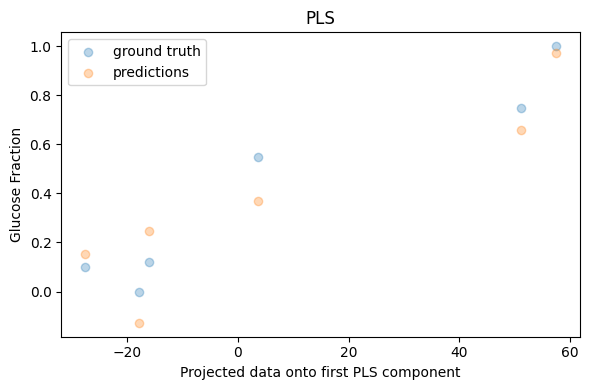

In [40]:
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(X_proj, y_test, alpha=0.3, label="ground truth")
y_pred = pls.predict(X_test)
ax.scatter(X_proj, y_pred, alpha=0.3, label="predictions")
ax.set(xlabel="Projected data onto first PLS component", ylabel="Glucose Fraction", title="PLS")
legend = ax.legend()

rmsep = root_mean_squared_error(y_test, y_pred)
print(f"RMSEP: {rmsep:.4f}")
plt.tight_layout()
plt.show()